In [ ]:
import torch
import numpy as np
from torch import nn # nn contains all of PyTorch's building blocks for DL
import matplotlib.pyplot as plt

# Check PyTorch version
torch.__version__

'2.10.0+cpu'

# 1. Data (preparing and loading)
Data can be anything:
- Excel sheet
- Images
- Audio
- DNA
- Text
- etc

ML/DL can be summarized into 2 main parts:
1. Numerical representation of the data
2. Build a model to regconize patterns in that numerical representation

In [ ]:
# Create *known* parameters
weight = 0.7
bias = 0.3

# Create
start = 0
end = 1
step = 0.02
X = torch.arange(start,end,step).unsqueeze(dim=1)
y = weight*X + bias

X[:10],y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [ ]:
len(X),len(y)

(50, 50)

## Splitting data into training and test sets (one of the most important step)



In [ ]:
# Create a train/test split
train_split = int(0.8*len(X))
X_train,y_train = X[:train_split],y[:train_split]
X_test,y_test = X[train_split:],y[train_split:]

len(X_train),len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

### "Visualize! Visualize! Visualize"

In [ ]:
def plot_predictions(train_data,
                     train_labels,
                     test_data,
                     test_labels,
                     predictions):
  """
  Plots training data, test data and compares the predictions
  """
  plt.figure(figsize=(10,7))

  # Plot traing data in blue
  plt.scatter(train_data,train_labels,c="b",s=4,label="Training data")

  # Plot test data in green
  plt.scatter(test_data,test_labels,c="g",s=4,label="Test data")

  # Are there predictions?
  if len(predictions) !=0:
    # plot the predictions if they exist
    plt.scatter(test_data,predictions,c="r",s=4,label="Predictions")

  # Show the legends
  plt.legend(prop={"size":14});

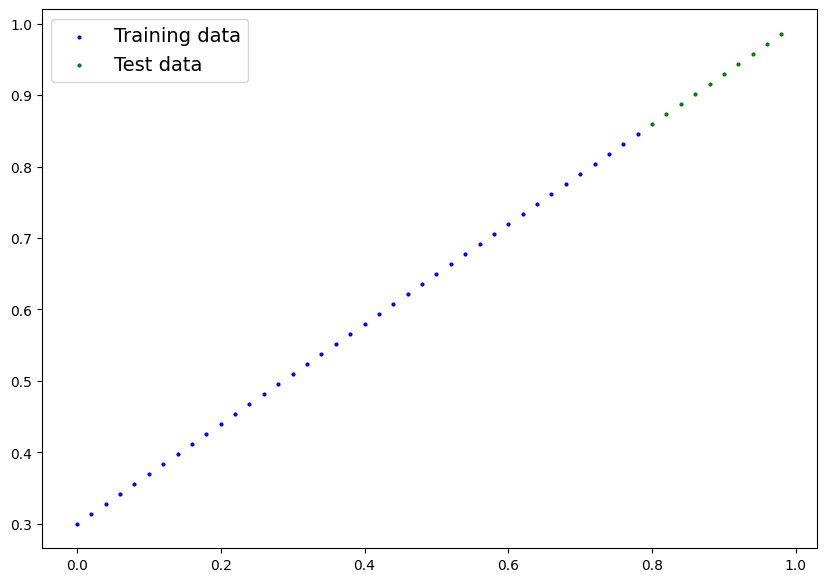

In [ ]:
plot_predictions(X_train,y_train,X_test,y_test,predictions=[])

# 2. Build Model
The following model is a simple class that
- Generate random values for the parameters (weight and bias)
- Take the training data as input and adjust the random parameters to better represent the ideal value

The way it works is through 2 main algorithm:
1. Gradient descent
2. Backpropagation

In [ ]:
# Create linear regression model class
class LinearRegressionModel(nn.Module): # <- almost everything in PyTorch inherits from nn.Module
  def __init__(self):
    super().__init__()
    # Initialize model parameters
    self.weight = nn.Parameter(torch.randn(1, # <- Start with a random weight and try to adjust it to the ideal weight
                                         requires_grad=True, # <- can this parameter be updated via gradient descent
                                         dtype=torch.float))
    self.bias = nn.Parameter(torch.randn(1,
                                         requires_grad=True,
                                         dtype=torch.float))
  # Forward method to define the computation in the model -> The forward method should be defined for your specific model so that it can overides the ones in nn.Module
  def forward(self, x: torch.Tensor) -> torch.Tensor: # <- x is the input data
    return self.weight * x + self.bias # -> Output a value based on x and the linear regression model

## PyTorch model building essentials
- `torch.nn` contains all the building blocks for computational graphs
- `torch.nn.Parameter` - what parameters our model should try and learn, often a PyTorch layer from ``torch.nn` will set these for us
- `torch.nn.Module` - The base class for all neural networks modules, if you subclass it, you should overwrite the `forward()` method
- `torch.optim` - This is where the optimizers in PyTorch locate, which will help with gradient descent
- def forward() - All nn.Module subclasses require you to overwrite forward(), this method defines what happen in the forward computation

### Checking the contents of our PyTorch model

Since we already have built a model, now let's see what's inside

To check our model parameters or what's inside the model then use
  `.parameters()`

In [ ]:
# Create a random seed
RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)

# Create an instance of the model (this model is a subclass of nn.Module)
model_0 = LinearRegressionModel()

# Check out the parameters
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [ ]:
# List the named parameters
model_0.state_dict()

OrderedDict([('weight', tensor([0.3367])), ('bias', tensor([0.1288]))])

## Making predictions using `torch.inference_mode()`
We can produce the predictions of a model using the simple following
    
    y_pred = model(X_train)

With `torch.inference_mode()` the gradients of the output value are not tracked/stored -> Benefit: Less memory usage

In [ ]:
# Make predictions with model
with torch.inference_mode(): # -> Turn off the tracking of the gradients -> Benefit: less memories usage
  y_preds = model_0(X_test)

y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

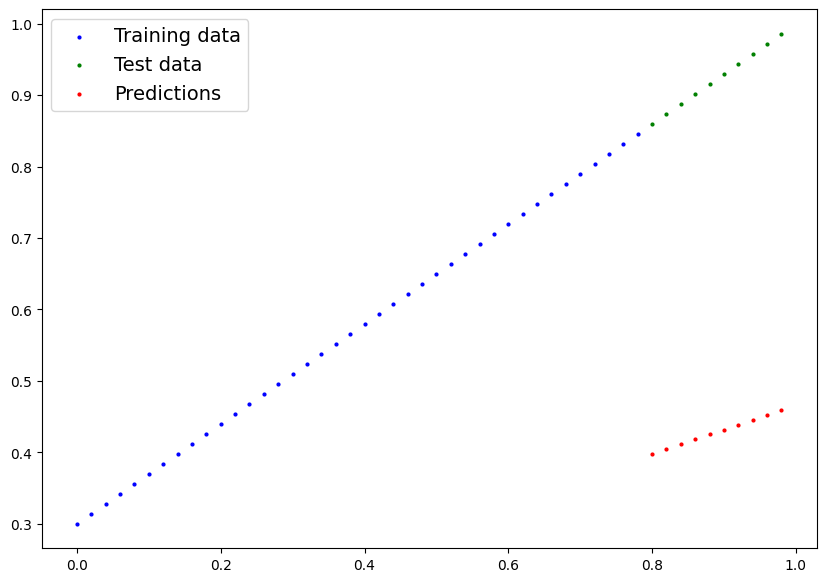

In [ ]:
plot_predictions(X_train,y_train,X_test,y_test,predictions=y_preds)

# 3. Train Model

One way to measure how wrong your model is to use a loss function

Things need to be trained:
- **Loss function** -> `nn.lossFnName` ,e.g. `nn.L1Loss`. To see more about loss functions visit https://docs.pytorch.org/docs/stable/nn.html#loss-functions
- **Optimizer:** Takes into account the loss of the model and adjust the parameters to improve the loss function -> `torch.optim.OptName`, e.g. `torch.optim.Adam`. To see more about optimizer visit https://docs.pytorch.org/docs/stable/optim.html.
  - Inside the optimizer, you often have to set 2 parameters:
    - `params` - the model parameters of the model
    - `lr` - learning rate

And specifically for PyTorch, we need:
- A training loop
- A testing loop

In [ ]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [ ]:
model_0.state_dict()

OrderedDict([('weight', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [ ]:
# Setup a loss function
loss_fn = nn.L1Loss()

# Setup an optimizer
optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.01) # -> learning rate = possibly the most important hyper parameter

## Building a traing and testing loop in PyTorch
A couple of things we need in a training loop:
1. Loop through the data
2. Forward pass (this involves data moving our data forward in the model `forward()`) to make predictions oon data
3. Calculate the loss (compare forward pass predictions to groudtruth)
4. Optimizer zero grad
5. Loss backward - move backward through the network to calculate the gradients of each of the parameters w.r.t the loss (**backpropagation**)
6. Optimizer step - use the optimizer to adjust the model's parametes to try to reduce the loss (**gradient descent**)

In [ ]:
# An epoch is one loop through the data (hyperparameter)
epochs = 200

# Track diff values
epoch_count = []
loss_values = []
test_loss_values = []

### Training
# 1.Loop through the data
for epoch in range(epochs):
  # Set the model to traing mode
  model_0.train() # train mode in PyTorch sets all the parameters that require gradients to True

  # 2.Forward pass
  y_pred = model_0(X_train)

  # 3.Calculate the loss
  loss = loss_fn(y_pred,y_train)
  # if epoch % 20 == 0:
  #   print(f"Loss at epoch {epoch}: {torch.round(loss,decimals=2)}")

  # 4.Optimizer zero grad
  optimizer.zero_grad() # ->Set the gradient to zero before updating because by default, the optimizer accumulate the gradient

  # 5. Backpropagation
  loss.backward()

  # Step the optimizer
  optimizer.step()

  # if epoch % 20 == 0:
  #   print(f"The model parameters at epoch {epoch}: {model_0.state_dict()}")

  ### Testing
  model_0.eval() # turn off diff. setting not needed for evaluation and testing
  with torch.inference_mode():
    # 2.Forward pass
    test_pred = model_0(X_test)

    # 3.Calculate the loss
    test_loss = loss_fn(test_pred,y_test)

  if epoch % 10 == 0:
    epoch_count.append(epoch)
    loss_values.append(loss)
    test_loss_values.append(test_loss)
    print(f"Epoch: {epoch} | Loss: {loss} | Test Loss: {test_loss}")
    print(f"The model parameters at epoch {epoch}: {model_0.state_dict()}")

Epoch: 0 | Loss: 0.31288138031959534 | Test Loss: 0.48106518387794495
The model parameters at epoch 0: OrderedDict({'weight': tensor([0.3406]), 'bias': tensor([0.1388])})
Epoch: 10 | Loss: 0.1976713240146637 | Test Loss: 0.3463551998138428
The model parameters at epoch 10: OrderedDict({'weight': tensor([0.3796]), 'bias': tensor([0.2388])})
Epoch: 20 | Loss: 0.08908725529909134 | Test Loss: 0.21729660034179688
The model parameters at epoch 20: OrderedDict({'weight': tensor([0.4184]), 'bias': tensor([0.3333])})
Epoch: 30 | Loss: 0.053148526698350906 | Test Loss: 0.14464017748832703
The model parameters at epoch 30: OrderedDict({'weight': tensor([0.4512]), 'bias': tensor([0.3768])})
Epoch: 40 | Loss: 0.04543796554207802 | Test Loss: 0.11360953003168106
The model parameters at epoch 40: OrderedDict({'weight': tensor([0.4748]), 'bias': tensor([0.3868])})
Epoch: 50 | Loss: 0.04167863354086876 | Test Loss: 0.09919948130846024
The model parameters at epoch 50: OrderedDict({'weight': tensor([0.

In [ ]:
torch.tensor(loss_values)

tensor([0.3129, 0.1977, 0.0891, 0.0531, 0.0454, 0.0417, 0.0382, 0.0348, 0.0313,
        0.0279, 0.0245, 0.0210, 0.0176, 0.0142, 0.0107, 0.0073, 0.0039, 0.0089,
        0.0089, 0.0089])

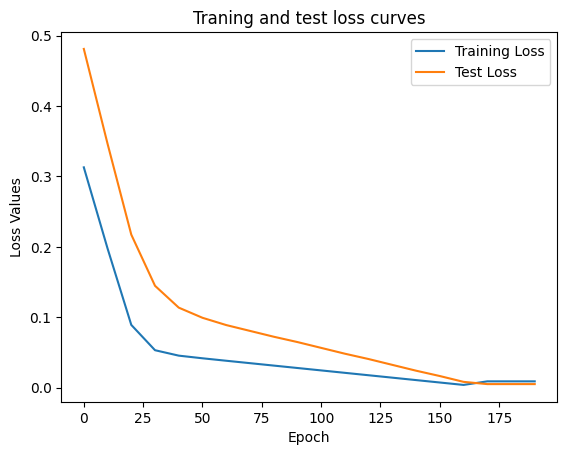

In [ ]:
# Plot the loss curve
plt.plot(epoch_count,np.array(torch.tensor(loss_values).numpy()), label="Training Loss")
plt.plot(epoch_count,np.array(torch.tensor(test_loss_values).numpy()),label="Test Loss")
plt.title("Traning and test loss curves")
plt.xlabel("Epoch")
plt.ylabel("Loss Values")
plt.legend()

In [ ]:
with torch.inference_mode():
  y_pred_new = model_0(X_test)

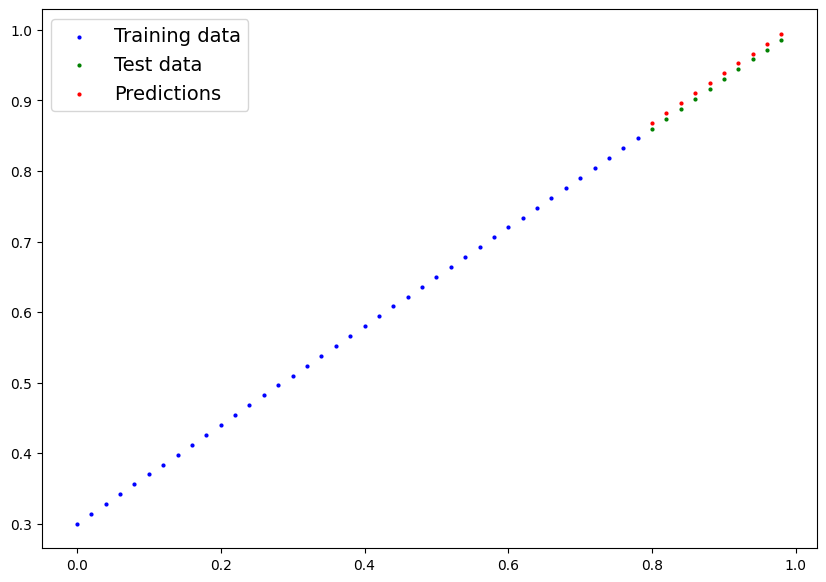

In [ ]:
plot_predictions(X_train,y_train,X_test,y_test,predictions=y_pred_new)

# 4. Saving a Model in PyTorch
Therer are 3 main methods for saving and loading models in PyTorch
1. `torch.save()` - Save a PyTorch object in Python's pickle format
2. `torch.load()` - Load a saved PyTorch object
3. `torch.nn.Module.load_state_dict()` - Load aa model's saved state dictionary

PyTorch save&load code: https://docs.pytorch.org/tutorials/beginner/saving_loading_models.html

In [ ]:
# Saving our PyTorch model
from pathlib import Path

# 1. Create models directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True,exist_ok=True)

# 2. Create models save path
MODEL_NAME = "LinearRegressionModel.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# 3. Save the model.state_dict
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_0.state_dict(),
           f=MODEL_SAVE_PATH)

Saving model to: models/LinearRegressionModel.pth


In [ ]:
!ls -1 models/

LinearRegressionModel.pth


# 5. Loading a PyTorch model

Since we saved our model's `state_dict()` rather the whole model, we create a new instance of our model class and load the saved `state_dict()` into that

In [ ]:
# To load in a saved state_dict() we have to instantiate a new instance of our model class
model_0_load = LinearRegressionModel()

# Load the saved model into our new instance of the model
model_0_load.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

<All keys matched successfully>

In [ ]:
model_0_load.state_dict()

OrderedDict([('weight', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [ ]:
# Make some predictions with the loaded model
model_0_load.eval()
with torch.inference_mode():
  y_pred_load = model_0_load(X_test)


In [ ]:
y_pred_load == y_pred_new

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

# 6. Exercise (Putting everything together)

In [ ]:
# Import
import torch
import matplotlib.pyplot as plt
from torch import nn
import math
import numpy as np
from pathlib import Path

Create device agnostic code.

This means if we've got access to a GPU, out code will use it.

If not the code will use CPU by default

In [ ]:
# Set device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


## 6.1 Preparing Data

Text(0.5, 1.0, 'Pure data')

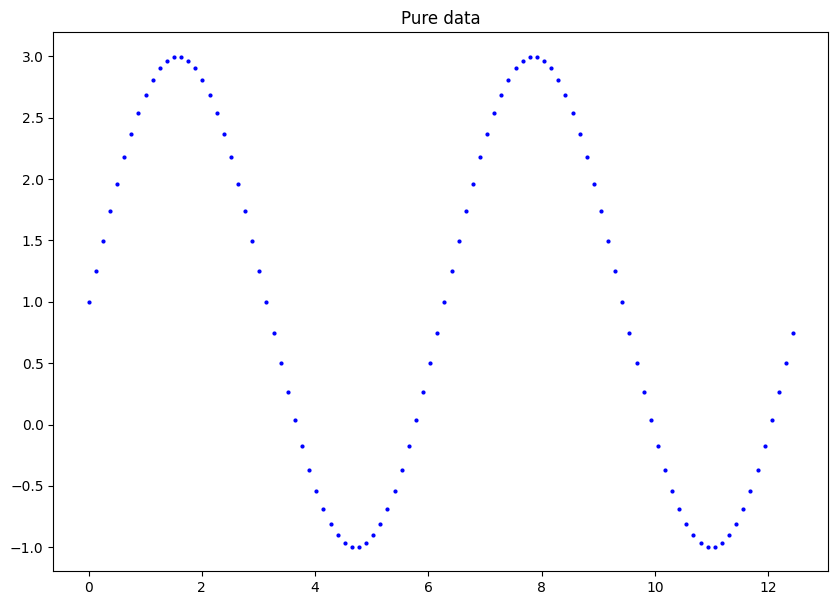

In [ ]:
# Create some data using sin function
A = 2
b = 1

start = 0
end = 4*math.pi
step = end/100
X = torch.arange(start,end,step,device=device)
y = A*torch.sin(X) + b

plt.figure(figsize=[10,7])
plt.scatter(X.cpu(),y.cpu(),c="b",s=4)
plt.title("Pure data")

In [ ]:
X.device, y.device

(device(type='cuda', index=0), device(type='cuda', index=0))

In [ ]:
def plot_predictions(train_data,
                     train_labels,
                     test_data,
                     test_labels,
                     predictions):
  """
  Plots training data, test data and compares the predictions
  """
  train_data_cpu = train_data.cpu()
  train_labels_cpu = train_labels.cpu()
  test_data_cpu = test_data.cpu()
  test_labels_cpu = test_labels.cpu()
  predictions_cpu = predictions.cpu()

  plt.figure(figsize=(10,7))

  # Plot traing data in blue
  plt.scatter(train_data_cpu,train_labels_cpu,c="b",s=4,label="Training data")

  # Plot test data in green
  plt.scatter(test_data_cpu,test_labels_cpu,c="g",s=4,label="Test data")

  # Are there predictions?
  if len(predictions) !=0:
    # plot the predictions if they exist
    plt.scatter(test_data_cpu,predictions_cpu,c="r",s=4,label="Predictions")

  # Show the legends
  plt.legend(prop={"size":14});

In [ ]:
torch.from_numpy(np.array([]))

tensor([], dtype=torch.float64)

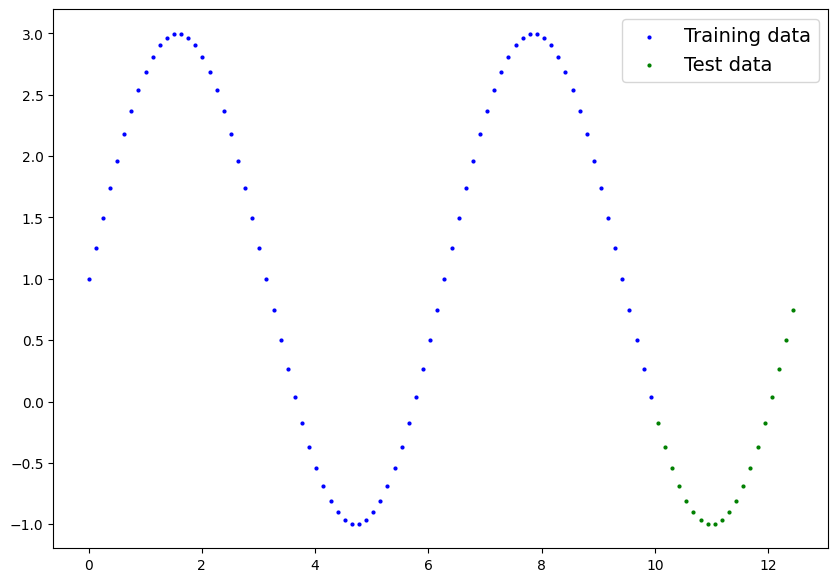

In [ ]:
# Preparing training and test datasets

training_sets = int(round(len(X)*0.8))
X_train = X[:training_sets]
y_train = y[:training_sets]
X_test = X[training_sets:]
y_test = y[training_sets:]

plot_predictions(X_train,y_train,X_test,y_test,predictions=torch.from_numpy(np.array([])))

## 6.2 Build Model

In [ ]:
class SinusoidalRegressionModel(nn.Module):
  def __init__(self):
    super().__init__()
    # Initialize the parameters
    self.a = nn.Parameter(torch.randn(1,
                         device=device,
                         requires_grad=True))
    self.b = nn.Parameter(torch.randn(1,
                         device=device,
                         requires_grad=True))

  def forward(self, x:torch.Tensor) -> torch.Tensor:
    return self.a*torch.sin(x) + self.b

In [ ]:
# Check the initialization of the model
RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)

model_1 = SinusoidalRegressionModel()

print(model_1.state_dict())

OrderedDict({'a': tensor([0.1940], device='cuda:0'), 'b': tensor([0.1391], device='cuda:0')})


## 6.3 Train Model

In [ ]:
# Loss Function
loss_fn = torch.nn.MSELoss()
# Optimizer
optimizer = torch.optim.Adam(params=model_1.parameters(),
                             lr=0.01)

# Initialize hyperparameter
epochs = 400
epoch_count = []
train_loss_values = []
test_loss_values = []

# Training loop
for epoch in range(epochs):
  # Turn on training mode
  model_1.train()

  # Forward
  y_pred = model_1(X_train)

  # Loss
  loss_train = loss_fn(y_pred,y_train)

  # optimizer 0 grad
  optimizer.zero_grad()

  # backpropagation
  loss_train.backward()

  # optimizer step
  optimizer.step()

  # evaluation
  model_1.eval()
  with torch.inference_mode():
    y_pred_test = model_1(X_test)
    loss_test = loss_fn(y_pred_test,y_test)

  if epoch % 20 == 0:
    epoch_count.append(epoch)
    train_loss_values.append(loss_train)
    test_loss_values.append(loss_test)
    print(f"Epoch: {epoch} | Training loss: {loss_train} | Test loss: {loss_test}")
    print(f"The model parameters at epoch {epoch}: {model_1.state_dict()}")

Epoch: 0 | Training loss: 2.858304738998413 | Test loss: 0.4262714087963104
The model parameters at epoch 0: OrderedDict({'a': tensor([0.2040], device='cuda:0'), 'b': tensor([0.1491], device='cuda:0')})
Epoch: 20 | Training loss: 2.057330369949341 | Test loss: 0.43364429473876953
The model parameters at epoch 20: OrderedDict({'a': tensor([0.4021], device='cuda:0'), 'b': tensor([0.3461], device='cuda:0')})
Epoch: 40 | Training loss: 1.4343868494033813 | Test loss: 0.44362297654151917
The model parameters at epoch 40: OrderedDict({'a': tensor([0.5912], device='cuda:0'), 'b': tensor([0.5281], device='cuda:0')})
Epoch: 60 | Training loss: 0.9808297157287598 | Test loss: 0.4475846290588379
The model parameters at epoch 60: OrderedDict({'a': tensor([0.7666], device='cuda:0'), 'b': tensor([0.6862], device='cuda:0')})
Epoch: 80 | Training loss: 0.6653809547424316 | Test loss: 0.4390873908996582
The model parameters at epoch 80: OrderedDict({'a': tensor([0.9265], device='cuda:0'), 'b': tensor([

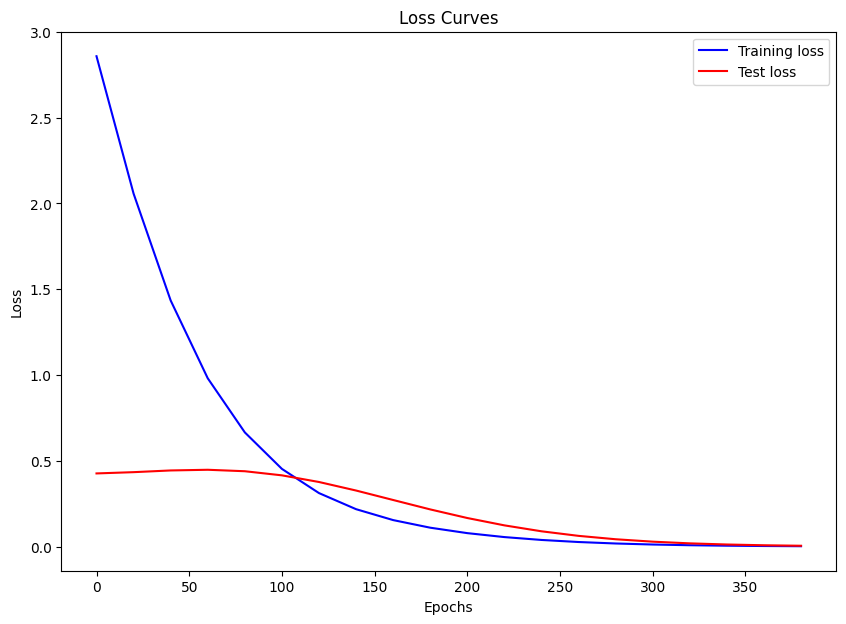

In [ ]:
# Plot the loss curves
plt.figure(figsize=[10,7])
plt.plot(epoch_count,np.array(torch.tensor(train_loss_values).cpu().numpy()),c="b",label="Training loss")
plt.plot(epoch_count,np.array(torch.tensor(test_loss_values).cpu().numpy()),c="r",label="Test loss")
plt.title("Loss Curves")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

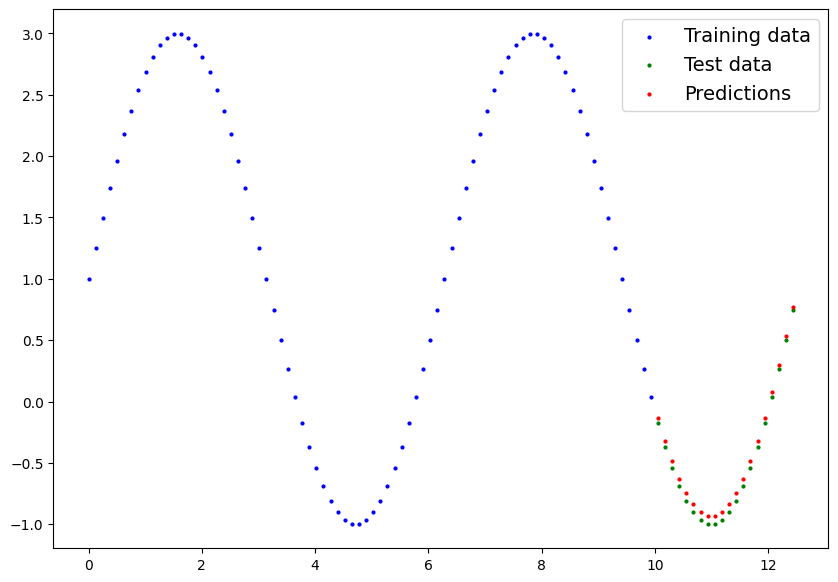

In [ ]:
# Plot the predicted values
with torch.inference_mode():
  y_pred_new = model_1(X_test)

plot_predictions(X_train,y_train,X_test,y_test,y_pred_new)

## 6.4 Save Model

In [ ]:
# Create a directory for models folder
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True,exist_ok=True)

# Create file for the model
MODEL_NAME = "SinusoidalRegressionModel.pth"
MODEL_SAVE_PATH = MODEL_PATH/MODEL_NAME

print(f"The model is saved in {MODEL_SAVE_PATH}")
torch.save(obj=model_1.state_dict(),f=MODEL_SAVE_PATH)

The model is saved in models/SinusoidalRegressionModel.pth


## 6.5 Load Model

In [ ]:
# Initialize a model to load the saved model
model_1_load = SinusoidalRegressionModel()
# Load the model to our "empty" model
model_1_load.load_state_dict(torch.load(MODEL_SAVE_PATH))

model_1_load.state_dict()

OrderedDict([('a', tensor([1.9492], device='cuda:0')),
             ('b', tensor([1.0150], device='cuda:0'))])

/tmp/ipykernel_2145/3933050471.py:2: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  y_true = A*np.sin(X_true.cpu()) + b


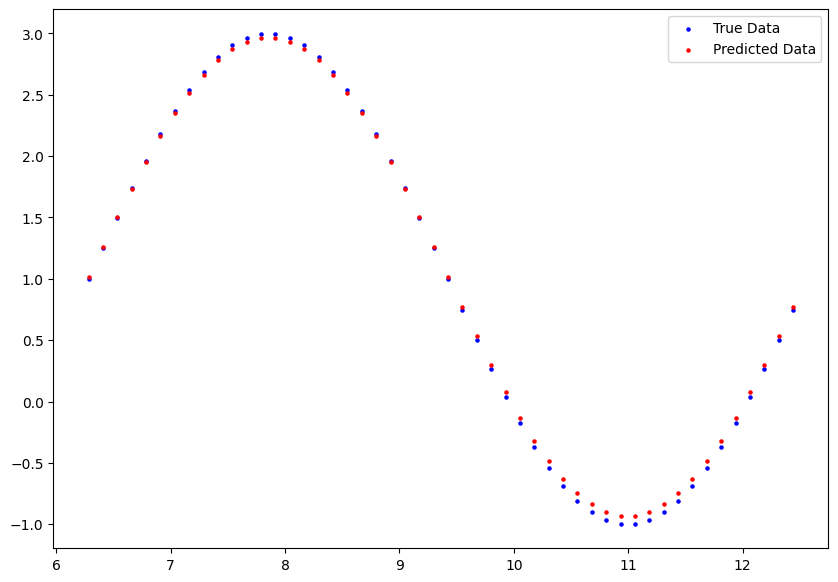

In [ ]:
X_true = torch.arange(2*math.pi,4*math.pi,step,device=device)
y_true = A*torch.sin(X_true) + b

model_1_load.eval()
with torch.inference_mode():
  y_pred_load = model_1_load(X_true)

plt.figure(figsize=[10,7])
plt.scatter(X_true.cpu(),y_true.cpu(),c="b",s=5,label="True Data")
plt.scatter(X_true.cpu(),y_pred_load.cpu(),c="r",s=5,label="Predicted Data")
plt.legend()